In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('../DATA/Employee-Attrition.csv')

In [3]:
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [5]:
df['Attrition'] = df['Attrition'].map({"Yes":1, "No": 0})

<Axes: >

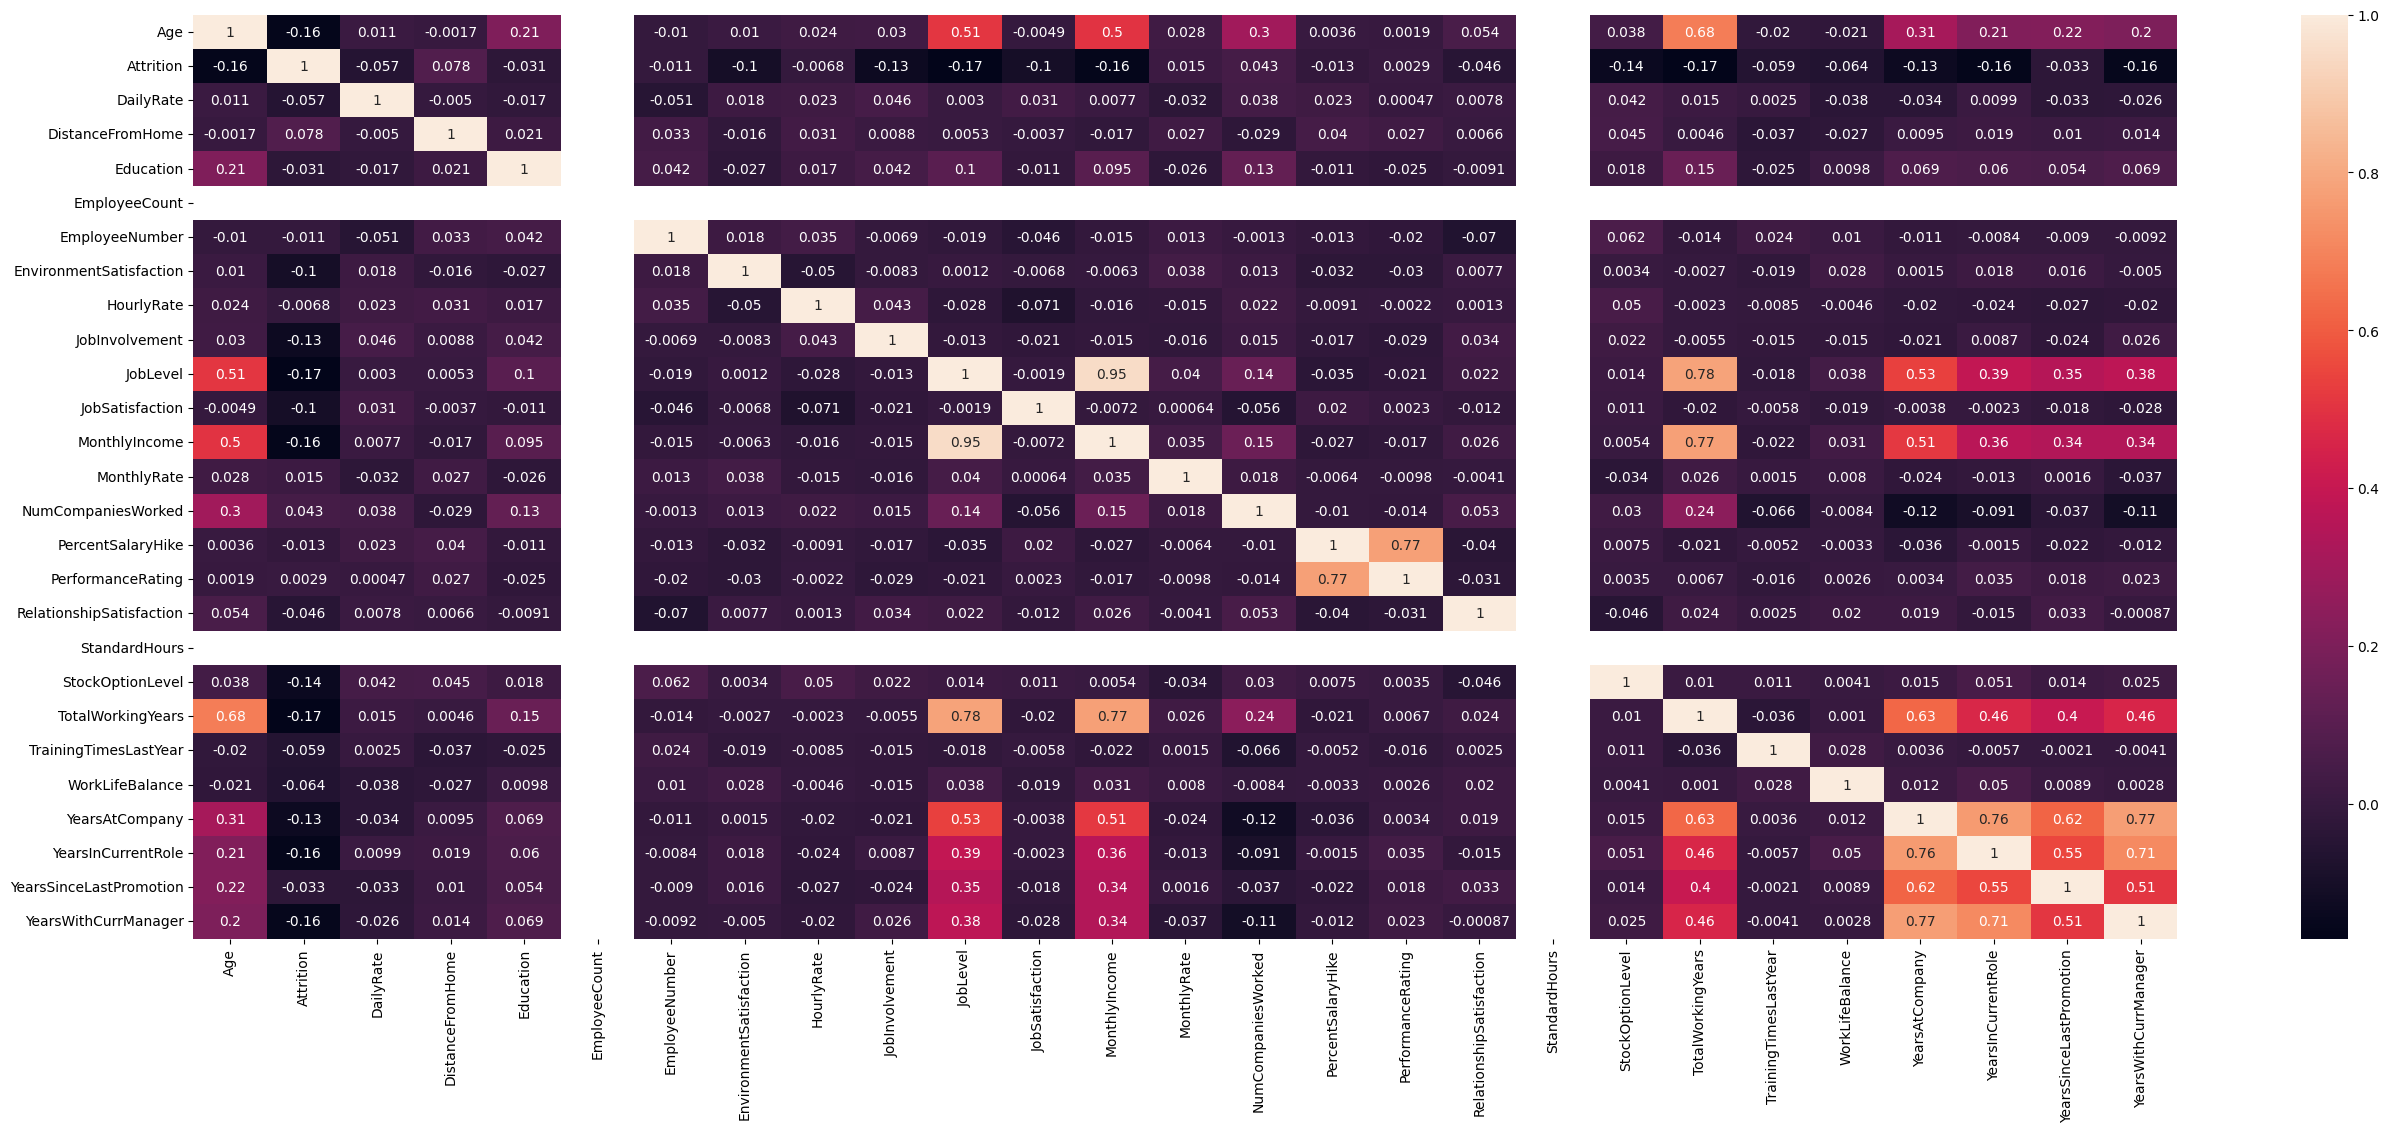

In [6]:
plt.figure(figsize=(32, 12))
sns.heatmap(df.corr(numeric_only=True), annot=True)

In [7]:
df['StandardHours'].unique()

array([80])

In [8]:
df['EmployeeCount'].unique()

array([1])

In [9]:
df['Over18'].unique()

array(['Y'], dtype=object)

In [10]:
df['EmployeeNumber'].unique()

array([   1,    2,    4, ..., 2064, 2065, 2068], shape=(1470,))

In [11]:
df = df.drop(['StandardHours', 'EmployeeCount', 'Over18', 'EmployeeNumber'], axis=1)

<Axes: >

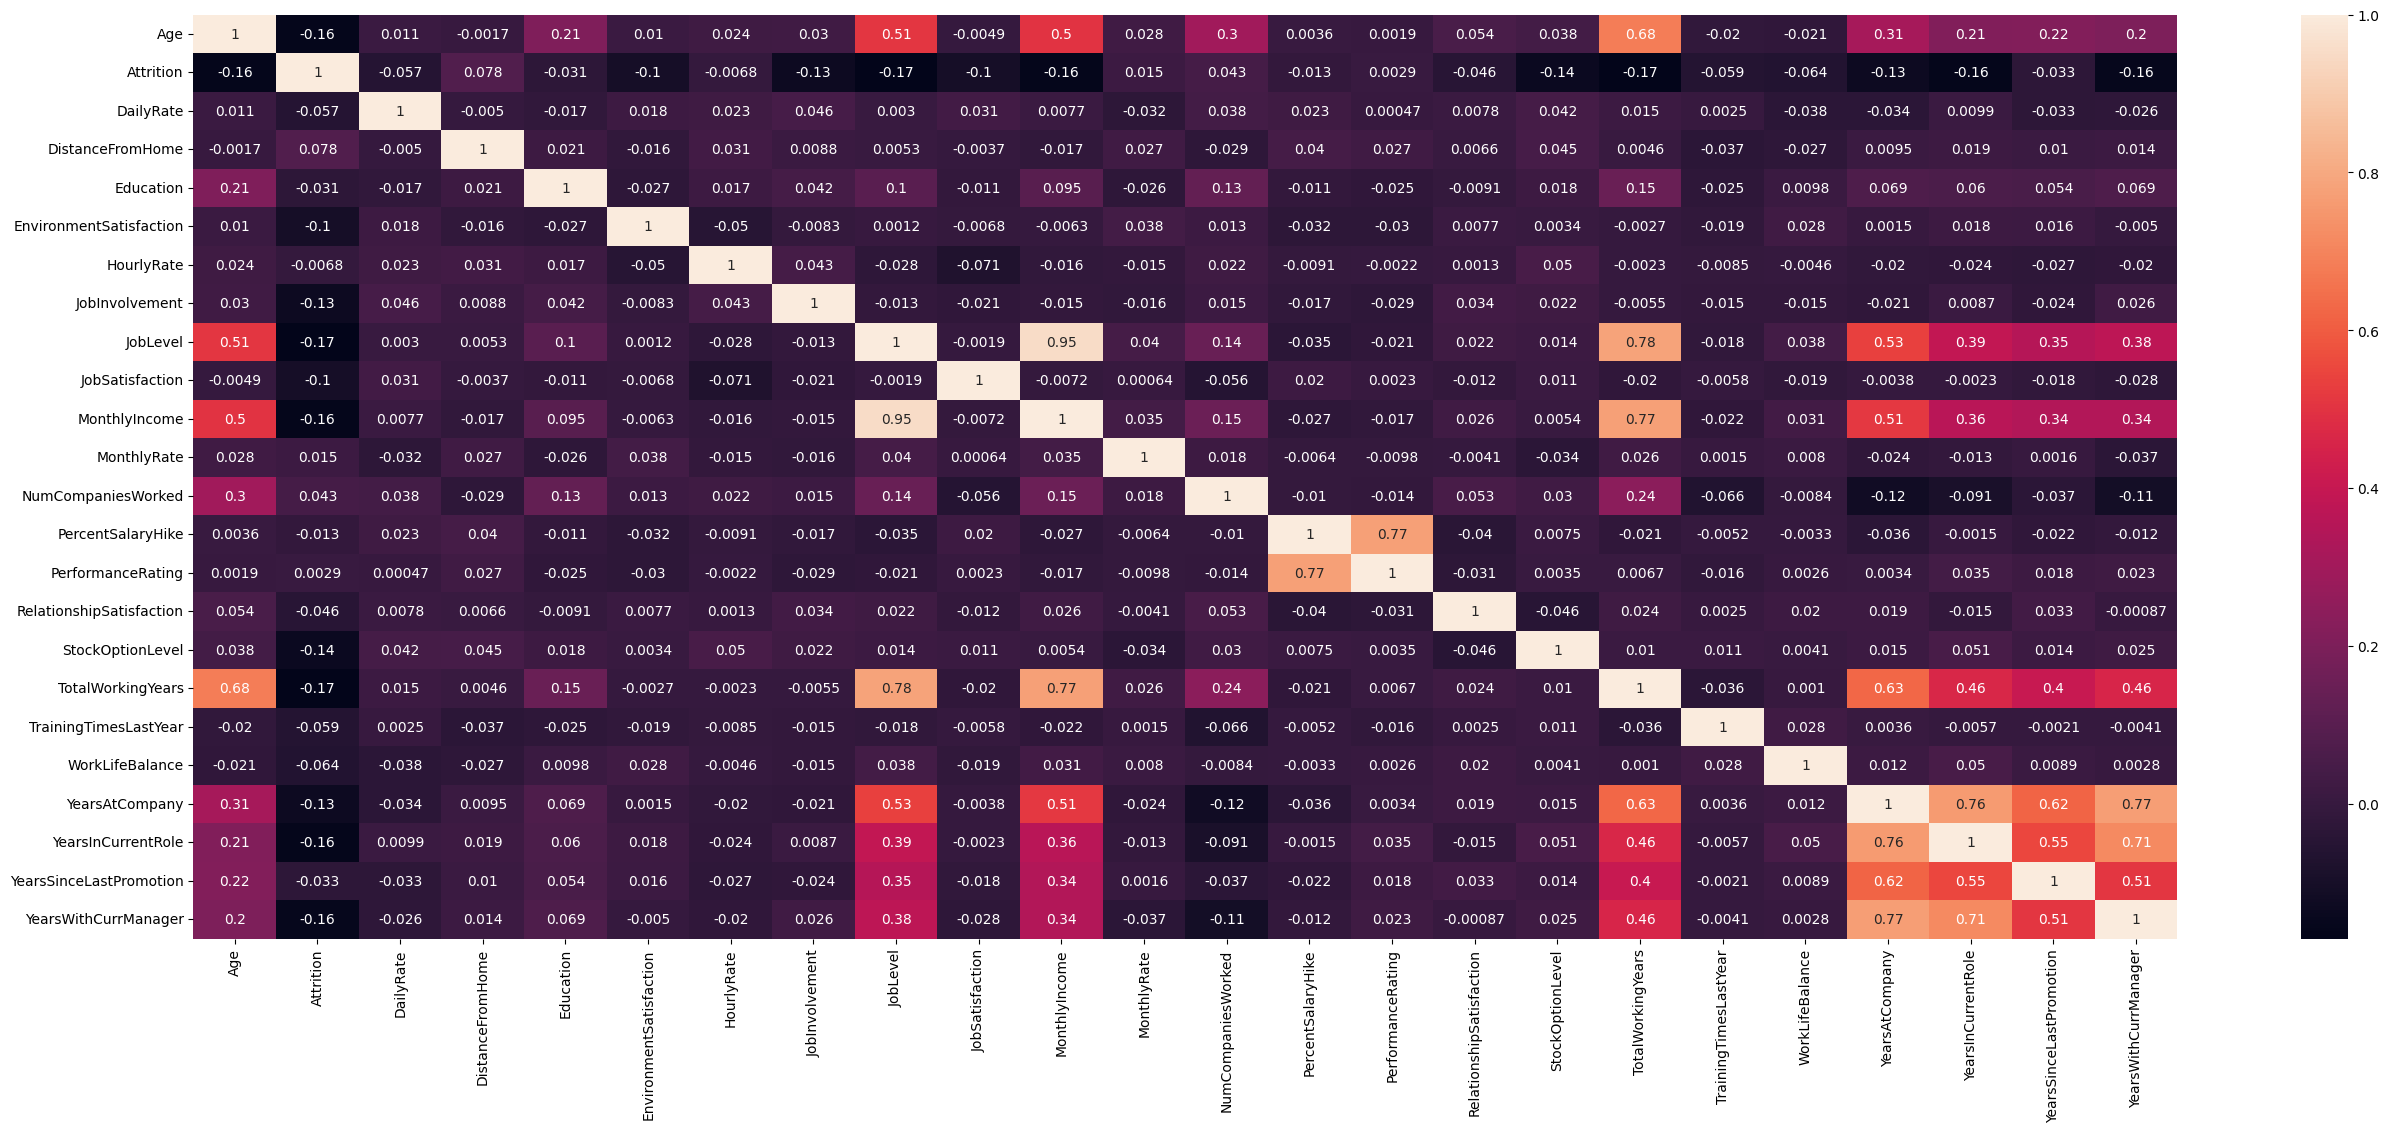

In [12]:
plt.figure(figsize=(32, 12))
sns.heatmap(df.corr(numeric_only=True), annot=True)

In [13]:
df.duplicated().sum()

np.int64(0)

<Axes: xlabel='Attrition', ylabel='count'>

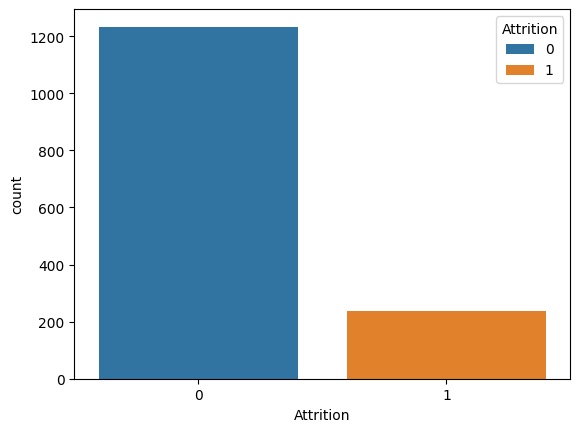

In [14]:
sns.countplot(x='Attrition', data=df, hue='Attrition')

In [15]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures, OneHotEncoder
from sklearn.linear_model import LogisticRegressionCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score, ConfusionMatrixDisplay, RocCurveDisplay
from sklearn.impute import KNNImputer

In [16]:
X = df.drop('Attrition', axis=1)

In [17]:
y = df['Attrition']

In [18]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=104, stratify=y)

In [19]:
num_features = X_train.select_dtypes(exclude='object').columns.tolist()
cat_features = X_train.select_dtypes(include='object').columns.tolist()

In [20]:
num_features

['Age',
 'DailyRate',
 'DistanceFromHome',
 'Education',
 'EnvironmentSatisfaction',
 'HourlyRate',
 'JobInvolvement',
 'JobLevel',
 'JobSatisfaction',
 'MonthlyIncome',
 'MonthlyRate',
 'NumCompaniesWorked',
 'PercentSalaryHike',
 'PerformanceRating',
 'RelationshipSatisfaction',
 'StockOptionLevel',
 'TotalWorkingYears',
 'TrainingTimesLastYear',
 'WorkLifeBalance',
 'YearsAtCompany',
 'YearsInCurrentRole',
 'YearsSinceLastPromotion',
 'YearsWithCurrManager']

In [21]:
cat_features

['BusinessTravel',
 'Department',
 'EducationField',
 'Gender',
 'JobRole',
 'MaritalStatus',
 'OverTime']

In [22]:
num_transformer = Pipeline([
    ('imputer', KNNImputer(n_neighbors=5)),
    ('scaler', StandardScaler())
])

In [23]:
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_features),
        ('num', num_transformer, num_features)
    ],
    remainder='passthrough'
)

In [24]:
pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LogisticRegressionCV(cv=10,
                                  penalty='l2',
                                  solver='lbfgs',
                                  Cs=10,
                                  max_iter=100_000,
                                  n_jobs=-1,
                                  random_state=104,
                                  class_weight='balanced'))
])

In [25]:
import warnings

warnings.filterwarnings('ignore', category=FutureWarning)

In [26]:
pipe.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transfor

In [27]:
y_pred = pipe.predict(X_test)
y_pred_proba = pipe.predict_proba(X_test)[:, 1]
y_pred_train_proba = pipe.predict_proba(X_train)[:, 1]

In [28]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
roc_auc_train = roc_auc_score(y_train, y_pred_train_proba)
roc_auc_test = roc_auc_score(y_test, y_pred_proba)

In [29]:
best_model = pipe.named_steps['model']
print(f"Лучшее значение C: {best_model.C_}")
print(f"Лучшее значение l1_ratio: {best_model.l1_ratio_}")

Лучшее значение C: [0.04641589]
Лучшее значение l1_ratio: [None]


In [30]:
accuracy

0.7551020408163265

In [31]:
precision

0.37373737373737376

In [32]:
recall

0.7872340425531915

In [33]:
roc_auc_train

0.8716077719654104

In [34]:
roc_auc_test

0.8257386510466018

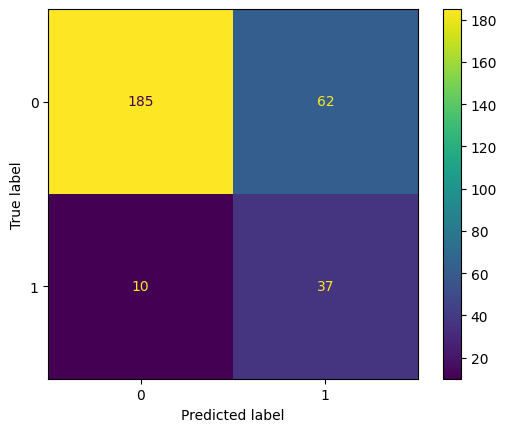

In [35]:
ConfusionMatrixDisplay.from_estimator(pipe, X_test, y_test);

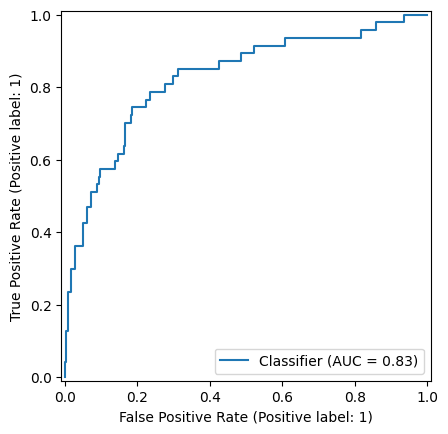

In [36]:
RocCurveDisplay.from_predictions(y_test, y_pred_proba);

In [37]:
pipe.fit(X, y)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transfor

In [38]:
y_pred_full_proba = pipe.predict_proba(X)[:, 1]

In [58]:
best_final_model = pipe.named_steps['model']
print(f"Лучшее значение C: {best_final_model.C_}")
print(f"Лучшее значение l1_ratio: {best_final_model.l1_ratio_}")

Лучшее значение C: [0.04641589]
Лучшее значение l1_ratio: [None]


In [40]:
roc_auc_full = roc_auc_score(y, y_pred_full_proba)

In [41]:
roc_auc_full

0.8656633164625404

In [42]:
df['BusinessTravel'].unique()

array(['Travel_Rarely', 'Travel_Frequently', 'Non-Travel'], dtype=object)

In [43]:
df['Department'].unique()

array(['Sales', 'Research & Development', 'Human Resources'], dtype=object)

In [44]:
df['EducationField'].unique()

array(['Life Sciences', 'Other', 'Medical', 'Marketing',
       'Technical Degree', 'Human Resources'], dtype=object)

In [45]:
df['JobRole'].unique()

array(['Sales Executive', 'Research Scientist', 'Laboratory Technician',
       'Manufacturing Director', 'Healthcare Representative', 'Manager',
       'Sales Representative', 'Research Director', 'Human Resources'],
      dtype=object)

In [46]:
df['MaritalStatus'].unique()

array(['Single', 'Married', 'Divorced'], dtype=object)

In [47]:
test_df = pd.DataFrame([
    {
        'Age': 35, 
        'BusinessTravel': 'Travel_Rarely', 
        'DailyRate': 1200, 
        'Department': 'Research & Development',
        'DistanceFromHome': 2, 
        'Education': 4, 
        'EducationField': 'Medical', 
        'EnvironmentSatisfaction': 4,
        'Gender': 'Male', 
        'HourlyRate': 80, 
        'JobInvolvement': 4, 
        'JobLevel': 3, 
        'JobRole': 'Healthcare Representative',
        'JobSatisfaction': 4, 
        'MaritalStatus': 'Married', 
        'MonthlyIncome': 9500, 
        'MonthlyRate': 15000,
        'NumCompaniesWorked': 1, 
        'OverTime': 'No', 
        'PercentSalaryHike': 15, 
        'PerformanceRating': 3,
        'RelationshipSatisfaction': 4, 
        'StockOptionLevel': 1, 
        'TotalWorkingYears': 10, 
        'TrainingTimesLastYear': 3,
        'WorkLifeBalance': 3, 
        'YearsAtCompany': 10, 
        'YearsInCurrentRole': 7, 
        'YearsSinceLastPromotion': 1, 
        'YearsWithCurrManager': 7
    },
    {
        'Age': 26, 
        'BusinessTravel': 'Travel_Frequently', 
        'DailyRate': 300, 
        'Department': 'Sales',
        'DistanceFromHome': 25, 
        'Education': 2, 
        'EducationField': 'Marketing', 
        'EnvironmentSatisfaction': 1,
        'Gender': 'Female', 
        'HourlyRate': 40, 
        'JobInvolvement': 1, 
        'JobLevel': 1, 
        'JobRole': 'Sales Representative',
        'JobSatisfaction': 1, 
        'MaritalStatus': 'Single', 
        'MonthlyIncome': 2300, 
        'MonthlyRate': 22000,
        'NumCompaniesWorked': 4, 
        'OverTime': 'Yes', 
        'PercentSalaryHike': 11, 
        'PerformanceRating': 3,
        'RelationshipSatisfaction': 1, 
        'StockOptionLevel': 0, 
        'TotalWorkingYears': 3, 
        'TrainingTimesLastYear': 1,
        'WorkLifeBalance': 1, 
        'YearsAtCompany': 3, 
        'YearsInCurrentRole': 2, 
        'YearsSinceLastPromotion': 2, 
        'YearsWithCurrManager': 0
    }
])

In [48]:
test_df

,Age,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,HourlyRate,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,35,Travel_Rarely,1200,Research & Development,2,4,Medical,4,Male,80,...,3,4,1,10,3,3,10,7,1,7
1,26,Travel_Frequently,300,Sales,25,2,Marketing,1,Female,40,...,3,1,0,3,1,1,3,2,2,0


In [49]:
probabilities = pipe.predict_proba(test_df)[:, 1]
predictions = pipe.predict(test_df)

In [50]:
print(f"--- Вероятность увольнения лояльного сотрудника: {probabilities[0]:.2%}")
print(f"--- Вероятность увольнения выгорающего сотрудника: {probabilities[1]:.2%}")
print(f"--- Уволится ли лояльный сотрудник: ДА") if predictions[0] == 1 else print(f"--- Уволится ли лояльный сотрудник: НЕТ")
print(f"--- Уволится ли выгорающий сотрудник: ДА") if predictions[1] == 1 else print(f"--- Уволится ли выгорающий сотрудник: НЕТ")

--- Вероятность увольнения лояльного сотрудника: 1.26%
--- Вероятность увольнения выгорающего сотрудника: 99.88%
--- Уволится ли лояльный сотрудник: НЕТ
--- Уволится ли выгорающий сотрудник: ДА


In [51]:
class_percents = df['Attrition'].value_counts(normalize=True) * 100

baseline_string = f"0: {class_percents[0]:.1f}%, 1: {class_percents[1]:.1f}%"
print(f"{baseline_string}")

0: 83.9%, 1: 16.1%


In [52]:
import json
import os

advanced_report = {
    "project": "Employee Attrition Prediction",
    "model": "LogisticRegressionCV",
    "trained_date": '2026-07',
    "test_parameters": {
        "cv": best_model.cv,
        "penalty": best_model.penalty,
        "solver":best_model.solver,
        "C": best_model.C_.tolist()[0],
    },
    "final_parameters": {
        "cv": best_final_model.cv,
        "penalty": best_final_model.penalty,
        "solver":best_final_model.solver,
        "C": best_final_model.C_.tolist()[0],
    },
    "metrics": {
        "Accuracy Score": accuracy,
        "Precision Score": precision,
        "Recall": recall,
        "ROC AUC Score Train": roc_auc_train,
        "ROC AUC Score Test": roc_auc_test,
        "ROC AUC Score Full": roc_auc_full,
        "Class Balance": baseline_string
    }
}


filename = "model_description.json"

with open(filename, "w", encoding="utf-8") as f:
    json.dump(advanced_report, f, indent=4, ensure_ascii=False)

In [53]:
from joblib import dump, load

In [54]:
dump(pipe, "model/employee_attrition_predict_logistic_regression_cv_2026_v1.pkl")

['model/employee_attrition_predict_logistic_regression_cv_2026_v1.pkl']

In [55]:
loaded_pipe = load("model/employee_attrition_predict_logistic_regression_cv_2026_v1.pkl")

In [56]:
loaded_pipe.predict(test_df)

array([0, 1])

In [57]:
loaded_pipe.predict_proba(test_df)[:, 1]

array([0.01262386, 0.99877285])